<a href="https://colab.research.google.com/github/eharmon8-sketch/Work-with-PyPhase/blob/experiment_star_data_aligned/star.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://gitlab.in2p3.fr/mlanger/pyPhase.git
%cd pyPhase
!pip install .

fatal: destination path 'pyPhase' already exists and is not an empty directory.
/content/pyPhase
Processing /content/pyPhase
  Preparing metadata (setup.py) ... done
  Created wheel for pyphase: filename=pyphase-2.0.0-py3-none-any.whl size=84461 sha256=34c808e8bd2ec27087da177be2e763a0907a5cb6fa518ae1837595eff0f86c8c
  Stored in directory: /tmp/pip-ephem-wheel-cache-ff0at7qm/wheels/d5/c7/01/47613ce339f3843cb612d6a98a9a97fdb7e6450bbcb5de96da
Successfully built pyphase
  Attempting uninstall: pyphase
    Found existing installation: pyphase 2.0.0
    Uninstalling pyphase-2.0.0:
      Successfully uninstalled pyphase-2.0.0


In [ ]:
import pyphase
from pyphase import *
import numpy as np

invalid escape sequence '\i'
invalid escape sequence '\i'


In [ ]:
#%% Choose image display to use
displayer = utilities.PyplotImageDisplayer()

In [ ]:
!pwd
%cd pyPhase/examples/

/content/pyPhase
[Errno 2] No such file or directory: 'pyPhase/examples/'
/content/pyPhase


/content/pyPhase/examples
(5, 2048, 2048)


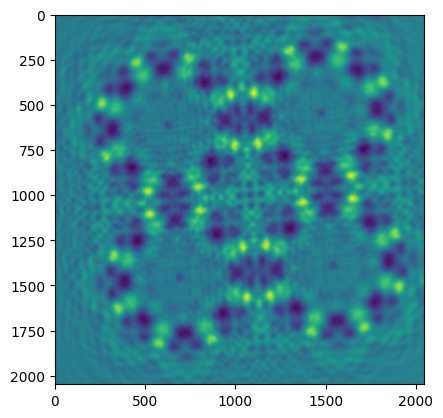

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
# Change working directory to the examples folder where the data and pixelsizes.txt reside
if os.path.exists('/content/pyPhase/examples'):
    %cd /content/pyPhase/examples

star_data = np.load('star_data_aligned.npy')
print(star_data.shape)
plt.imshow(star_data[0])
#%% Load dataset
data = dataset.NanomaxPreprocessed2D('star', version='test')

In [ ]:
pyphase.dataset.h5py

<module 'h5py' from '/usr/local/lib/python3.12/dist-packages/h5py/__init__.py'>

To load a different dataset, you would modify the call to `pyphase.dataset.NanomaxPreprocessed2D` by changing the `name` and `version` parameters. For example, if there's another dataset named 'my_new_data' with version 'v1.0', you would change the line accordingly. You might need to know the available dataset names and versions provided by `pyphase` or stored locally.

In [ ]:
# Example of loading a new dataset
# Replace 'new_dataset_name' and 'new_version' with actual values if you have them.
# For now, we'll try to load 'another_star' dataset if it exists.

# Ensure the dataset module is imported if not already
from pyphase import dataset

try:
    new_data = dataset.NanomaxPreprocessed2D(name='another_star', version='test')
    print(f"Successfully loaded new dataset: {new_data.name} (version: {new_data.version})")
    # You can then inspect the new dataset, e.g., print its info
    # print(new_data.info())
except Exception as e:
    print(f"Could not load the new dataset. Please check if 'another_star' or your desired dataset name/version exists. Error: {e}")

### Saving data to an `.npy` file

To save a NumPy array to a `.npy` file, you can use `np.save()`. This is useful for persisting arrays that you've computed, so you can load them later without recalculating.

In [ ]:
import numpy as np

# Assuming 'phase' and 'attenuation' arrays are available from previous cells
# If not, you would use your own numpy arrays here.

# Define filenames for saving
phase_filename = 'reconstructed_phase.npy'
attenuation_filename = 'reconstructed_attenuation.npy'

# Save the arrays
np.save(phase_filename, phase)
np.save(attenuation_filename, attenuation)

print(f"'{phase_filename}' and '{attenuation_filename}' saved successfully.")
print("You can find these files in the current working directory (/content/pyPhase/examples).")

### Loading data from an `.npy` file

To load data back from a `.npy` file into a NumPy array, you use `np.load()`.

In [ ]:
# Load the saved arrays back
loaded_phase = np.load(phase_filename)
loaded_attenuation = np.load(attenuation_filename)

print(f"'{phase_filename}' loaded. Shape: {loaded_phase.shape}")
print(f"'{attenuation_filename}' loaded. Shape: {loaded_attenuation.shape}")

# You can verify they are the same as the original arrays
# print(f"Phase data is identical: {np.array_equal(phase, loaded_phase)}")
# print(f"Attenuation data is identical: {np.array_equal(attenuation, loaded_attenuation)}")

In [ ]:
pyphase.config.registrator.NumberOfResolutions = 8
pyphase.config.registrator.MaximumNumberOfIterations = 6000

data.align_projection()

Aligning position 1
Aligning position 2
Aligning position 3
Aligning position 4


In [ ]:
import pyphase
print("Contents of pyphase.config:")
print([attr for attr in dir(pyphase.config) if not attr.startswith('__')])

try:
    print("\nChecking data.registrator:")
    print([attr for attr in dir(data.registrator) if not attr.startswith('__')])
except AttributeError:
    print("\ndata object has no registrator attribute.")

Contents of pyphase.config:
['Parallelize', 'Parallelizer', 'Path', 'Tomography', 'Utilities', 'backend_name', 'default_method', 'importlib', 'memory_per_core', 'memory_per_node', 'min_memory_per_core', 'number_of_cores', 'number_of_nodes', 'pyphase_path', 'registrator', 'sys', 'tomography', 'viewer']

Checking data.registrator:

data object has no registrator attribute.


In [ ]:
import math
# Injecting missing alias into the library's module
phaseretrieval.m_ = math

# Phase retrieval from a dataset using CTF
retriever = phaseretrieval.CTF(data)

# Modify regularisation parameter
retriever.alpha = [1e-3, 1e-8] # [LF, HF]

1e-05
[5.92410521e-09 6.04296279e-09]


In [ ]:
import math
# Ensure library patch and retriever definition
phaseretrieval.m_ = math
retriever = phaseretrieval.CTF(data)
retriever.alpha = [1e-3, 1e-8]

# Reconstruct
phase, attenuation = retriever.reconstruct_projection(dataset=data, projection=0)

1e-05
[5.92410521e-09 6.04296279e-09]


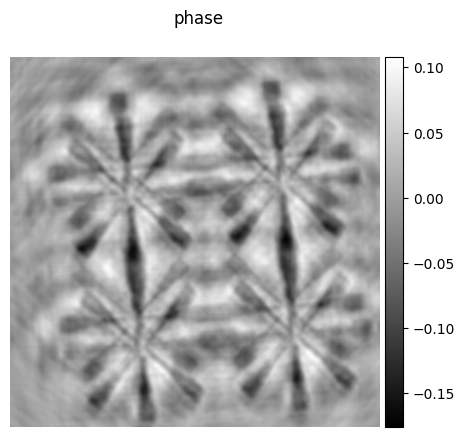

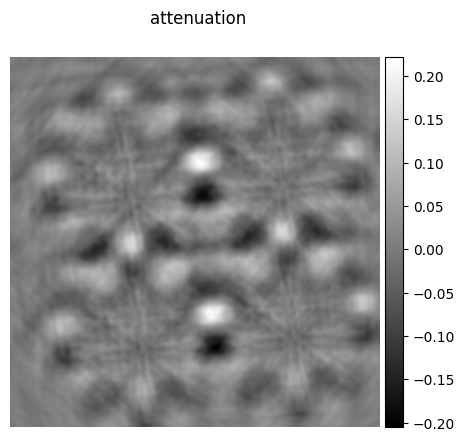

In [ ]:
#%% Display reconstruction
displayer.close_all()
displayer.display(data.get_image(projection=0), title='phase')
displayer.display(data.get_image(projection=0, image_type='attenuation'), title='attenuation')

In [ ]:
#%% Phase retrieval from images
# Acquisition parameters
energy=13 #keV
effective_distance=np.array([0.010054, 0.0155, 0.0178, 0.019, 0.0203])
pixel_size = np.array([0.005924, 0.006043])*1e-6

nyp = nxp = 4096
ny = nx = 2048

In [ ]:
#%% Load images
ID = np.zeros((len(effective_distance), nyp, nxp))
for N in range(len(effective_distance)):
    ID[N] = data.get_projection(projection=0, position=N, pad=True)

In [ ]:
import numpy as np
import math
from pyphase import phaseretrieval

# 1. Patch missing math alias in the module
phaseretrieval.m_ = math

# 2. Define the patched propagator for NumPy 2.0 compatibility
def patched_simple_propagator(self, pxs, Lambda, z):
    fx = np.fft.fftfreq(self.nfx, pxs[0])
    fy = np.fft.fftfreq(self.nfy, pxs[1])
    Fx, Fy = np.meshgrid(fx, fy)
    f2 = Fx ** 2 + Fy ** 2
    # Use np.complex128 instead of the string "complex_"
    H = np.zeros([self.ND, self.nfy, self.nfx], dtype=np.complex128)
    for distance in range(self.ND):
        H[distance,:,:] = np.exp(-1j * np.pi * Lambda * z[distance] * f2)
    return H

# 3. Apply the patch by finding the base class through HIO_ER
# HIO_ER inherits from PhaseRetrieval (or a class that does)
base_class = phaseretrieval.HIO_ER.__mro__[1]
base_class.simple_propagator = patched_simple_propagator

# Phase retrieval from images using HIO_ER
retriever = phaseretrieval.HIO_ER(shape=ID[0].shape, pixel_size=[pixel_size[0], pixel_size[1]], distance=effective_distance, energy=energy, pad=1)

# Modify parameters
retriever.alpha = [1e-3, 1e-8]
retriever.iterations_hio = 2
retriever.iterations_er = 2
retriever.iterations = 2

1e-05
[5.924e-09 6.043e-09]
1e-05
[5.924e-09 6.043e-09]


In [ ]:
#%% Reconstruct
import numpy as np
import math
import os
import importlib
from pyphase import phaseretrieval, dataset

# 1. EMERGENCY FIX: Restore np.dtype to stop RecursionError
# If np.dtype was monkey-patched in a previous run, reload numpy to get the original back
if hasattr(np.dtype, '__name__') and '_patched' in np.dtype.__name__:
    importlib.reload(np)

# 2. Ensure working directory
if not os.path.exists('pixelsizes.txt'):
    %cd /content/pyPhase/examples

# 3. Re-apply library patches for NumPy 2.0
phaseretrieval.m_ = math

# Use MRO to find the base class safely
base_class = phaseretrieval.HIO_ER.__mro__[1]

def patched_simple_propagator(self, pxs, Lambda, z):
    fx = np.fft.fftfreq(self.nfx, pxs[0])
    fy = np.fft.fftfreq(self.nfy, pxs[1])
    Fx, Fy = np.meshgrid(fx, fy)
    f2 = Fx ** 2 + Fy ** 2
    # Fix: use np.complex128 directly
    H = np.zeros([self.ND, self.nfy, self.nfx], dtype=np.complex128)
    for distance in range(self.ND):
        H[distance,:,:] = np.exp(-1j * np.pi * Lambda * z[distance] * f2)
    return H
base_class.simple_propagator = patched_simple_propagator

# 4. Define acquisition parameters and data
energy = 13
effective_distance = np.array([0.010054, 0.0155, 0.0178, 0.019, 0.0203])
pixel_size = np.array([0.005924, 0.006043]) * 1e-6
nyp = nxp = 4096

data = dataset.NanomaxPreprocessed2D('star', version='test')
ID = np.zeros((len(effective_distance), nyp, nxp))
for N in range(len(effective_distance)):
    ID[N] = data.get_projection(projection=0, position=N, pad=True)

# 5. Initialize retriever
retriever = phaseretrieval.HIO_ER(shape=ID[0].shape, pixel_size=[pixel_size[0], pixel_size[1]], distance=effective_distance, energy=energy, pad=1)
retriever.alpha = [1e-3, 1e-8]
retriever.iterations_hio = 2
retriever.iterations_er = 2
retriever.iterations = 2

# 6. Execute reconstruction with string-constant patching for NumPy 2.0
try:
    phase, attenuation = retriever.reconstruct_image(ID=star_data)
except TypeError as e:
    if "'complex_'" in str(e):
        # Directly patch the constant in the bytecode of the internal algorithm
        func = phaseretrieval.HIO_ER._algorithm
        if hasattr(func, '__func__'):
            func = func.__func__
        new_consts = tuple(c if c != 'complex_' else 'complex128' for c in func.__code__.co_consts)
        func.__code__ = func.__code__.replace(co_consts=new_consts)
        phase, attenuation = retriever.reconstruct_image(ID=star_data)
    else:
        raise e

1e-05
[5.924e-09 6.043e-09]
1e-05
[5.924e-09 6.043e-09]
========== Iterations 1 ==========
========== HIO-ER iter. 1 ==========
Distance 0 error: 2.8e-05
Distance 1 error: 7.4e-05
Distance 2 error: 4e-05
Distance 3 error: 5.8e-05
Distance 4 error: 5.8e-05
========== Iterations 1 ==========
========== HIO-ER iter. 2 ==========
Distance 0 error: 6.1e-05
Distance 1 error: 8.6e-05
Distance 2 error: 4e-05
Distance 3 error: 5.3e-05
Distance 4 error: 5.2e-05
========== Iterations 1 ==========
========== HIO-ER iter. 3 ==========
Distance 0 error: 0.00016
Distance 1 error: 0.00012
Distance 2 error: 5.7e-05
Distance 3 error: 6.1e-05
Distance 4 error: 7.3e-05
========== Iterations 1 ==========
========== HIO-ER iter. 4 ==========
Distance 0 error: 6.9e-05
Distance 1 error: 0.00011
Distance 2 error: 4.7e-05
Distance 3 error: 5.4e-05
Distance 4 error: 6.2e-05
========== Iterations 2 ==========
========== HIO-ER iter. 1 ==========
Distance 0 error: 6e-05
Distance 1 error: 9.1e-05
Distance 2 error: 

In [ ]:
from pyphase import utilities
displayer = utilities.PyplotImageDisplayer()

# Define ny and nx for resizing
# These values are derived from the acquisition parameters or data shape, e.g., star_data.shape[1:3]
ny, nx = 2048, 2048

#%% Display reconstruction
# Note: 'phase' and 'attenuation' variables are expected to be defined
# by the previous reconstruction cell (Wp1t-3XAQ-u7).
# Please ensure you run the reconstruction cell before this display cell.
displayer.close_all()
displayer.display(utilities.resize(phase, [ny, nx]), title='phase')
displayer.display(utilities.resize(attenuation, [ny, nx]), title='attenuation')

NameError: name 'phase' is not defined

In [ ]:
import numpy as np
np.load()

<function numpy.load(file, mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII', *, max_header_size=10000)>